# Predicting Voter Turnout Percent Using Demographic, Economic, & Housing Data
### 2025 Virginia Gubernatorial Election

#### Preparation

- [Github link](https://github.com/Ohughes-2/DSSS_Final_Assessment)

- Number of words: 1567

- Runtime: 11:07 minutes (*Memory 16 GB, CPU 11th Gen Intel Core i7‑1165G7 @ 2.80GHz*)

- Coding environment: Podman

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) 

- Additional library : None

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[Back To Top]](#Table-of-contents)

![Virginia Turnout Map](Turnout_Map.jpg)

Within any democratic style of government, the election is the foundational principle of representative law making. Despite this, no state within the U.S. requires its residents to vote, making voter turnout a key feature of every election. Particularly within the State of Virginia, where elections are held every year, off-years tend to see lower turnout than presidential election years ([see past VA elections](https://www.elections.virginia.gov/resultsreports/registrationturnout-statistics/)). Because of this, counteracting this off-year imbalance is a focus of both primary parties (Democrats and Republicans).

### Literature

One side of the political science argument asserts that ‘there is nothing more to political geography than the distribution of economic and demographic characteristics across a city, state, or region’ (Buchanon et. al 2022). However, this overgeneralizes the opinions held by a populace, the desire of said populace to vote, and again ignores that voting is not compulsory for U.S. citizens. Despite this, certain groups are far more likely to vote than others, specifically: white people are more likely to vote than black people and latinos by 4% and 20% respectively, older, retirement age citizens far outstrip recent high school and university graduates, and registered republicans are more likely to vote than registered democrats (Barber and Holbein 2022).  

Aside from the personal characteristics of a voter, the geography of a region also plays a significant role in one’s likelihood to vote. Barber and Holbein describe ‘Turnout Deserts’ which are expansive regions where turnout is consistently low. Of these is Appalachia, a rural mountainous region that extends through western Virginia (2022). Yet, it is often rural areas that see consistently high turnout as said communities are often close-knit while urban areas see a level of personal anonymity that limits collective political participation (Buchanon et al. 2022). Tamas et. al note that the largest concentration of Democrats are in dense cities, while Republicans tend to cluster in more rural suburban and agricultural areas. Given that denser regions generally see lower turnout, abnormal shifts in turnout are usually centered in cities, associating Democrat victories with high voter turnout (2022). 

These patterns prove relevant to the 2025 Virginia Gubernatorial election which saw a resounding victory for Democrat Abigail Spamberger as she won with 57.58% of the vote, the largest vote share in a gubernatorial election since 2009 (VPAP 2025). However, political reporter Ryan Nadeau explains that turnout between the 2021 and 2025 elections was near constant while the large margin of victory was explained by ‘decreased turnout in several Republican areas.’ This contrasts the concept proposed above that turnout is inherently partisan and supports its nature as a measure of civic engagement; providing a basis for predicting turnout with community demographic and economic data.


## Research questions

[[Back To Top]](#Table-of-contents)

Both Buchanon et. al and Barder and Holbein assert that location and political activity of major parties play a substantial role in an area's voter turnout. Though cultural regions and density classifications (urban, suburban, rural) are often ambiguous while the involvement of political parties is difficult to quantify. This leaves demographic and economic variables as the most accessible variables for prediction of voter participation, leaving us with these questions:

Can random forest regression accurately predict the census tract level voter turnout seen in the 2025 Virginia gubernatorial election?

Which demographic and economic attributes identified by SHAP feature importance are most strongly associated with high voter turnout? 

## Data

[[Back To Top]](#Table-of-contents)

![Data Preprocessing Method](Data_Preprocessing.jpg)

### Preprocessing 

This model made use of an extensively preprocessed dataset that used 4 sources of data. The processing outline is visible in the above chart and specific information and code is located in this [.IPYNB file](https://github.com/Ohughes-2/DSSS_Final_Assessment/blob/main/ASGN_Prep_2.ipynb). 

The sources of this data can be found here:

| Data | Source |
|----------|----------|
| Census Tract Shapefile   | [U.S. Census Tiger Lines](https://www.census.gov/cgi-bin/geo/shapefiles/index.php?year=2025&layergroup=Census+Tracts)  |
| Voting Precinct Shapefile    | [Redistricting Data Hub: Pulled from 21MetcalfJ Github](https://github.com/21MetcalfJ/2024Precincts) |
| Election Results .csv    | [Election Results](https://enr.elections.virginia.gov/results/public/virginia/elections/2025-November-General)  |
| ACS Demographic/Economic Data    | [U.S. Census Data Tables](https://data.census.gov/all?g=040XX00US51&d=ACS+5-Year+Estimates+Data+Profiles)  |


### Cleaning

To ensure that the complete data was ready for modelling, two cleaning steps are required. First, dropping NaN values in the dependent variable removes 8 rows while removing all non-percent features except area, population density, total population, geometry and GEOID (for mapping) leaves the final dataset with 2190 rows and 356 features.  

In [1]:
# Begin tracking runtime
import time
start = time.time()

In [2]:
## Import Libraries
import geopandas as gpd

## Load in analysis ready data from my Github Repo
url = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/complete_data.zip"
cd = gpd.read_file(url)
# Drop NaN values in the dependent variable: Should be 8 rows
cd = cd.dropna(subset=["Turnoutpct"])

# Keep these non percent columns and turnoutpct
keep_cols = ["GEOID", "geometry", "ALAND", "Turnoutpct", "Popden_Km", "Total_popu"]

# Identify percent columns (0–100)
percent_cols = [
    col for col in cd.columns
    if col not in keep_cols
    and cd[col].dtype != 'object'
    and cd[col].max() <= 100
]

# Final set of columns to keep
final_cols = keep_cols + percent_cols
cd = cd[final_cols]


# Print Lengths
print(f"Rows: {len(cd)}")
print(f"Features: {cd.shape[1]}")

Rows: 2190
Features: 356


### LASSO

LASSO regression was the method of feature selection for this model. After dropping the ID, dependent variable, and geometry of the dataset, an 80/20 train-test split was applied to the LASSO selection algorithm. Of the 356 features, 90 were selected with an alpha score of 0.149 highlighting that ACS data simultaneously contains many correlated variables and many linearly significant features. 

The table of the 20 highest LASSO coefficients is printed below. Features describing English and German ancestry and percent over 65 years old corroborate the notions presented earlier that generally white and older communities see high voter turnout. The highest coefficient was the population with a bachelor's and master's or doctoral degree, suggesting the importance of education level. Lastly, 6 features directly tied to household income are present in the top 20 indicating household income plays a larger role than any other demographic or economic grouping.

In [3]:
# Import Libraries for LASSO Regression Feature Selection
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.impute import SimpleImputer

# Data
# cd is the voterturnout and census variable gpd dataframe

# Create an array with all column except turnout percent
# Create a dataframe with just the turnout percent
X = cd.drop(columns=["Turnoutpct", "geometry", "GEOID"])
y = cd["Turnoutpct"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Impute NaN values with median
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Standardize predictors so that mean = 0 and sd = 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Split the data 5 different ways and select the α that
# reduces prediction error the most
lasso = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso.fit(X_train_scaled, y_train)

# Select non-zero coefficient features
features = X.columns.to_numpy()
lasso_mask = ~np.isclose(lasso.coef_, 0.0)
lasso_features = features[lasso_mask].tolist()

# Create a table with the feature coefficients
lasso_coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": lasso.coef_,
    "abs_coefficient": np.abs(lasso.coef_)
})

# Select rows where coefficient is non 0
# Set the order as descending
lasso_selected_table = (
    lasso_coef_table
    .loc[~np.isclose(lasso_coef_table["coefficient"], 0.0)]
    .sort_values("abs_coefficient", ascending=False)
)

# Inspect
print("LASSO alpha (λ):", lasso.alpha_)
print("Count of LASSO features:", len(lasso_features))
#display(lasso_selected_table.head(20))

LASSO alpha (λ): 0.14874774546456696
Count of LASSO features: 90


In [4]:
# Create a table with the 20 features with the highest
# linear coefficient
features_table = pd.DataFrame({
    "Variable": [
        "Bachelor_r", "State_of_r", "English_y",
        "Asian", "Worked_fro", "Household_1",
        "$50,000_to", "ALAND", "With_a_dis", "With_priva",
        "$500,000_t", "Less_tha_2", "Armed_Forces",
        "Other_rela", "With_food", "2_rooms", 
        "$150,000_t", "German_y", "$100,000_t",
        "Popdem_Km"
    ],
    "Type": [
        "Percent (0–100)", "Percent (0–100)", "Percent (0–100)",
        "Percent (0–100)", "Percent (0–100)", "Percent (0–100)",
        "Percent (0–100)", "Numeric", "Percent (0–100)",
        "Percent (0–100)", "Percent (0–100)", "Percent (0–100)",
        "Percent (0–100)", "Percent (0–100)", "Percent (0–100)",
        "Percent (0–100)", "Percent (0–100)", "Percent (0–100)",
        "Percent (0–100)", "Numeric"
    ],
    "Description": [
        "Population with a bachelor's and master's or doctoral degree",
        "Population born and living in Virginia",
        "Population with English Ancestry",
        "Population Identifying as Asian",
        "Population Working from Home",
        "Households with a Resident Aged 65+",
        "Households with Income Between \$50k and \$100k",
        "Land Area of the Census Tract (square meters)",
        "Population with a Disability",
        "Population with Private Health Insurance",
        "Households with Income Between \$500k and \$1m",
        "Households with Income Less than \$50k",
        "Population Employed by the U.S. Military",
        "Households with a Non-Spouse/Non-Child Relative Resident",
        "Population Using Food Stamps/SNAP",
        "Population Living in a 2-room Dwelling",
        "Households with Income Between \$150k and \$200k",
        "Population with German Ancestry",
        "Households with Income Between \$100k and \$150k",
        "Population Density (people per km²)"
    ],
    "Coefficient": [
        2.191765, 1.740047, 1.032149, -1.021214, 1.014343,
        0.938750, -0.806358, 0.691406, -0.605443, 0.600199,
        0.570294, -0.499173, -0.421802, -0.399402, -0.380067,
        -0.379605, -0.327817, 0.309422, -0.301738, -0.293520
    ]
})

features_table

,Variable,Type,Description,Coefficient
0,Bachelor_r,Percent (0–100),Population with a bachelor's and master's or d...,2.191765
1,State_of_r,Percent (0–100),Population born and living in Virginia,1.740047
2,English_y,Percent (0–100),Population with English Ancestry,1.032149
3,Asian,Percent (0–100),Population Identifying as Asian,-1.021214
4,Worked_fro,Percent (0–100),Population Working from Home,1.014343
5,Household_1,Percent (0–100),Households with a Resident Aged 65+,0.938750
6,"$50,000_to",Percent (0–100),Households with Income Between \$50k and \$100k,-0.806358
7,ALAND,Numeric,Land Area of the Census Tract (square meters),0.691406
8,With_a_dis,Percent (0–100),Population with a Disability,-0.605443
9,With_priva,Percent (0–100),Population with Private Health Insurance,0.600199


## Methodology

[[Back To Top]](#Table-of-contents)

![Methodology](Methodology.jpg)

### Random Forest

A random forest model was chosen as it measures non linear feature relationships with minimal computational effort. This proves vital given 90 features are present after dimensionality reduction. The model avoids overfitting despite potentially weak linear relationships and easily manages the mix of percent features and raw measures. Validation involved a 5-fold cross-validation with max depth, min leaf samples, and max features per split values. This validation ensures that the final model can run with ideal parameters that optimize the R2 values. 

LASSO assesses the linear relationship only between a feature and turnout. Despite this, the 90 selected features still maintain levels of interaction that the random forest can assess. For example, using population density as a proxy for the urban/rural split, the population density may interact with education level in a non linear way reflecting regional variations presented in the literature.

In [5]:
# Import lbraries needed for random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# Define the hyperparameters in a grid
# Max-dpeth, minimum leaf samples, and maximum features per split
hp_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 1.0]
}

# Grid search with 5-fold CV
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=23),
    param_grid = hp_grid, # use the set parameters
    cv=5, # 5 fold validation
    scoring='r2', # error metric
    n_jobs=-1, # Use all availble cpu cores
    return_train_score=True # check overfitting later
)

# Use scaled predictors from before
grid.fit(X_train_scaled, y_train)

# Print the best combination of hyperparameters
print("Best hyperparameters:", grid.best_params_)
print(f"Best CV R-squared: {grid.best_score_:.3f}")

# Run a model using the best hyperparemters
best_params = grid.best_params_
best_model = RandomForestRegressor(random_state=20, **best_params)
best_model.fit(X_train_scaled, y_train)

# Inspect the R2 values
train_r2 = r2_score(y_train, best_model.predict(X_train_scaled))
test_r2 = r2_score(y_test, best_model.predict(X_test_scaled))

#print(f"Train R-squared: {train_r2:.3f}")
#print(f"Test R-squared: {test_r2:.3f}")

# Store results and print
rf_results = {
    'CV_R2': grid.best_score_,
    'Train_R2': train_r2,
    'Test_R2': test_r2
}
pd.DataFrame([rf_results])

Best hyperparameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4}
Best CV R-squared: 0.681


,CV_R2,Train_R2,Test_R2
0,0.680566,0.91012,0.707531


### SHAP & Additional Outputs

The following code displays the outputs seen in methodology chart: the observed versus predicted scatterplot, MAE value, SHAP beeswarm plot, and mapped residuals. The results of these outputs, along with the model results above, will be analyzed in the following section. 

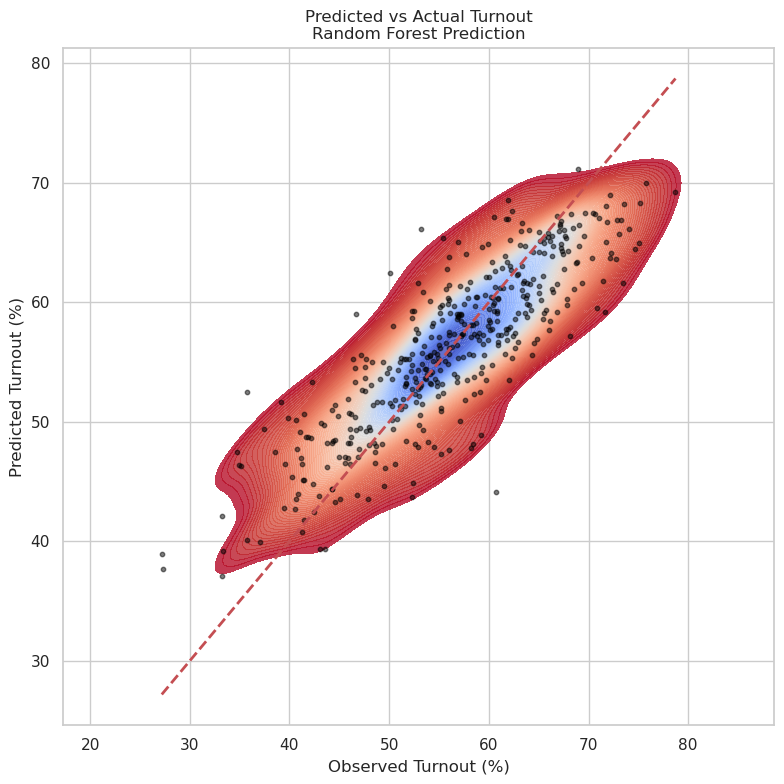

In [6]:
# Scatterplot with observed and predicted values
# import needed libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Locate predicted values
y_pred = best_model.predict(X_test_scaled)

# create a df for the plot
values_plot = pd.DataFrame({
    "Observed" : y_test,
    "Predicted" : y_pred
})

# Set the style of plot using seaborn
sns.set(style="whitegrid")
plt.figure(figsize = (8, 8))

# Density scatter using seaborn kdeplot
sns.kdeplot(
    data=values_plot,
    x = "Observed",
    y = "Predicted",
    fill = True,
    cmap = "coolwarm_r",
    thresh = 0.05,
    levels = 100,
    alpha = 0.8
)

# Add scatter points on top
plt.scatter(
    values_plot["Observed"],
    values_plot["Predicted"],
    s = 10,
    color = "black",
    alpha = 0.5 # translucent
)


# 45° reference line
min_val = min(values_plot.min())
max_val = max(values_plot.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Observed Turnout (%)")
plt.ylabel("Predicted Turnout (%)")
plt.title("Predicted vs Actual Turnout\nRandom Forest Prediction")

plt.tight_layout()
plt.show()

In [7]:
# Compute MAE (Already using percent)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} percentage points")

MAE: 3.80 percentage points


In [8]:
# Hide cell output
!pip install shap > /dev/null 2>&1

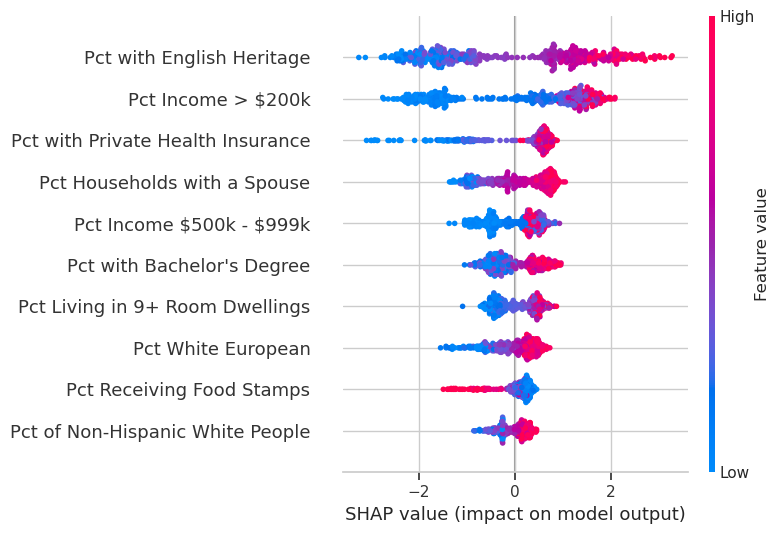

In [9]:
import shap

# SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the TEST set
shap_values = explainer.shap_values(X_test_scaled)

# 10 most important column determined from
# previous runs
column_names = {
    "Bachelor_1": "Pct with Bachelor's Degree",
    "White alon": "Pct White European",
    "$200,000 o": "Pct Income > \$200k",
    "With Food": "Pct Receiving Food Stamps",
    "English_y": "Pct with English Heritage",
    "White": "Pct of Non-Hispanic White People",
    "With priva": "Pct with Private Health Insurance",
    "Spouse": "Pct Households with a Spouse",
    "$500,000 t": "Pct Income \$500k - \$999k",
    "9 rooms or": "Pct Living in 9+ Room Dwellings",
}

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=[column_names.get(col, col) for col in X.columns],
    plot_type="dot",
    max_display=10  # show top 10 features
)

In [10]:
## Map the residuals of the model
# Predict turnout for all tracts
cd["Predicted"] = best_model.predict(scaler.transform(imputer.transform(X)))

# New residuals column
cd["Residual"] = cd["Turnoutpct"] - cd["Predicted"]

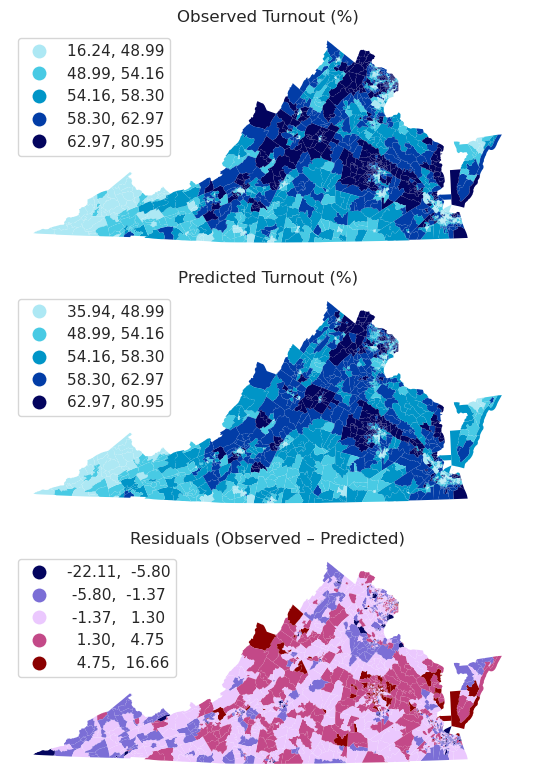

In [11]:
# Import mapping library
import mapclassify
from matplotlib.colors import LinearSegmentedColormap

# Compute shared breaks for Observed + Predicted
vals = pd.concat([cd["Turnoutpct"], cd["Predicted"]])
q5 = mapclassify.Quantiles(vals, k=5)

# Create the figure and axes
rev_bins = q5.bins[::-1]
fig, axes = plt.subplots(3, 1, figsize=(24, 8))

# Create custom blue color scheme
custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#ade8f4", "#48cae4", "#0096c7", "#023ea8", "#03045e"])
diverging_5 = LinearSegmentedColormap.from_list(
    "blue_purple_red_5",
    ["#03045e", "#7B6ED6", "#ebc9ff", "#C44A8A", "#8b0000"])


# Observed turnout 
cd.plot(
    column="Turnoutpct",
    cmap=custom_blues,
    legend=True,
    scheme="user_defined",
    classification_kwds={"bins": q5.bins},
    edgecolor="none",
    linewidth=0,
    ax=axes[0]
)
leg = axes[0].get_legend()
leg._loc = 2
axes[0].set_title("Observed Turnout (%)")
axes[0].axis("off")

# Predicted turnout 
cd.plot(
    column="Predicted",
    cmap=custom_blues,
    legend=True,
    scheme="user_defined",
    classification_kwds={"bins": q5.bins},
    edgecolor="none",
    linewidth=0,
    ax=axes[1]
)
leg = axes[1].get_legend()
leg._loc = 2
axes[1].set_title("Predicted Turnout (%)")
axes[1].axis("off")

# Residuals 
# Quantiles plot to display an equal amount
# of overpredictions as underpredictions
cd.plot(
    column="Residual",
    cmap=diverging_5,
    legend=True,
    scheme="fisher_jenks",
    k=5,
    edgecolor="none",
    linewidth=0,
    ax=axes[2]
)
leg = axes[2].get_legend()
leg._loc = 2
axes[2].set_title("Residuals (Observed – Predicted)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Stop tracking time
end = time.time()
print(f"Runtime: {end - start:.2f} seconds")

Runtime: 666.47 seconds


## Results and discussion

[[Back To Top]](#Table-of-contents)

### RF Results

The results of the model prediction show a validation R2 of 0.68, a train R2 of 0.91, and a test R2 0.71. The validation and test R2 indicate a well generalized, high predictive capability asserting that 71% of variability in turnout percent can be explained with the 90 selected features. Despite this, overfitting is still present as seen within the gap between the train and test R2, though the ideal parameters (max depth = 10, min leaf samples = 4, max features = 0.5) constrain the model to avoid extreme overfitting based error. 

### Scatterplot and MAE

The Mean Absolute Error of 3.8 describes that the average prediction is off by plus or minus 3.8 percentage points. This can be seen within the scatterplot that generally follows the perfect 45 degree line. The model performs best in tracts with a turnout percent between 50%-70%, though increases in overpredictions occur below 50% and increases in underpredictions occur above 70%. 


### SHAP Plot

The ten most significant SHAP features reveal 4 primary patterns of voter turnout influence. First, high values associated with upper-middle and high economic status are associated with high turnout, while high values associated with low economic status are associated with low turnout. Third, high values in households with a spouse present are associated with high turnout. Lastly, in accordance with the literature, high values of white/european heritage are heavily associated with high turnout. 

#### Maps

The maps of observed and predicted values both display the same broader trend of turnout, though the issues predicting high and low turnout mentioned in the scatterplot section are visible geographically. Moreover, clear spatial clustering of both high and low residuals is present as a direct result of the lack of spatial features within the model. Literature supports the importance of ‘turnout deserts’ and regional variations in turnout, and such data would need to be added in order to reduce these patterns of over and under prediction. 

### Discussion

Despite the successful results of this model and connection with claims from the literature, several limitations persist. Because census tracts and precincts do not share geometry the spatial allocation applied during the preprocessing merge produces estimates of turnout rather than a known count. ACS statistics are also estimates and sample errors are not considered in this analysis, and the most recent ACS data comes from 2024. Despite these faults, this analysis suggests a strong relationship between demographic/economic features and turnout, and the ability for random forest models to use this relationship for prediction. Additionally, this model corroborates previous conclusions that white citizens are more likely to vote while asserting that higher economic status is the most important to predicting voter turnout.

## Conclusion

[[Back To Top]](#Table-of-contents)

The random forest model undoubtedly captured a robust connection between the ACS features and voter turnout with a testing R2 of 0.71 and MAE of 3.8, while the SHAP analysis highlighted income, education, and white heritage as the most significant predictive measures. This coincides with previous conclusions made about the connections between demography and political geography, though a perfect model would include spatially explicit variables and further consideration of sampling errors. Additionally, turnout is unquestionably and greatly affected by party mobilization, though this is incredibly difficult to quantify at the precinct or tract level. Despite this, this model proves that, particularly when considering generalized regional trends, that training in a machine learning model on demographic and economic data is a justified method of predicting voter turnout in Virginia. 

## References

[[Back To Top]](#Table-of-contents)

Barber, M. and Holbein, J.B. (2022) “400 million voting records show profound racial and geographic disparities in voter turnout in the United States,” PLOS ONE. Edited by N. Lupu, 17(6), p. e0268134. Available at: https://doi.org/10.1371/journal.pone.0268134.

Buchanan, R., Dias, M. and Wlezien, C. (2022) On collective representation. Edward Elgar Publishing. Available at: https://doi.org/10.4337/9781800379619.00041.

Nadeau, R. (no date) Lower voter turnout in Virginia’s Republican districts paves way for Democrats | WRIC ABC 8News, WRIC. Available at: https://www.wric.com/news/politics/local-election-hq/lower-voter-turnout-republican-districts/ (Accessed: April 9, 2026).

Tamas, B., Johnston, R. and Pattie, C. (2022) “The impact of turnout on partisan bias in U.S. House elections, 1972–2018*,” Social Science Quarterly, 103(1), pp. 181–192. Available at: https://doi.org/10.1111/ssqu.13115.

Virginia Department of Elections (Virginia Department of Elections) Virginia Dept. of Elections: Registration/Turnout Reports, Registration/Turnout Reports. Available at: https://www.elections.virginia.gov/resultsreports/registrationturnout-statistics/ (Accessed: April 13, 2026).

VPAP (2025) VPAP.org, Nov. 2025 Turnout: Statewide and Local. Available at: https://www.vpap.org/visuals/visual/locality-turnout-compared-to-statewide-nov-2025/.